In [1]:
from lcdb.db import LCDB
from lcdb.analysis import LearningCurve, LearningCurveGroup, LearningCurveExtractor, merge_curves
#from lcdb.analysis.json import 

import json

from tqdm import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

In [6]:
dfs = {}

d_datasets = set()

def f(r):
    if type(r) != str:
        return None
    s = (r.replace("'", '"').replace("], \"metrics", "]\", \"metrics").replace("values\": [", "values\": \"[ ").replace("True", "true").replace("False", "false"))
    return LearningCurve.from_json(s)

for k in [
    "lcdb.workflow.sklearn.KNNWorkflow",
    #"lcdb.workflow.sklearn.LibLinearWorkflow",
    #"lcdb.workflow.sklearn.LibSVMWorkflow",
    #"lcdb.workflow.sklearn.TreesEnsembleWorkflow",
    #"lcdb.workflow.xgboost.XGBoostWorkflow"
]:
    dfs[k] = pd.read_csv(f"{k}.csv")
    dfs[k]["learning_curve"] = dfs[k]["learning_curve"].apply(f)
    dfs[k]["runtimes"] = dfs[k]["runtimes"].apply(lambda r: json.loads(r) if type(r) == str else None)
    d_datasets |= set(pd.unique(dfs[k]["m:openmlid"]))

In [7]:
d_datasets = sorted(d_datasets)
d_workflows = sorted(dfs.keys())

In [8]:
import openml
from tqdm import tqdm

ds_meta_features = {}

for openmlid in tqdm(d_datasets):

    if openmlid not in ds_meta_features:
        # Load the dataset by ID
        dataset = openml.datasets.get_dataset(int(openmlid))  # Replace with your dataset ID

        # Get basic metadata
        ds_meta_features[openmlid] = dataset.qualities


100%|██████████| 2/2 [00:00<00:00, 733.08it/s]


In [9]:
def get_ds_meta_features(openmlid):
    return ds_meta_features[openmlid]["NumberOfInstances"], ds_meta_features[openmlid]["NumberOfFeatures"], 

def get_data_complexity(openmlid):
    return ds_meta_features[openmlid]["NumberOfInstances"] * ds_meta_features[openmlid]["NumberOfFeatures"], 

In [10]:
import pandas as pd

#d_workflows = sorted(df_full.keys())
#d_datasets = set()
#for workflow in d_workflows:
#    d_datasets |= set([int(d) for d in pd.unique(df_full[workflow]["m:openmlid"])])
d_datasets = sorted(d_datasets, key=get_data_complexity)

In [11]:
mean_runtimes = np.zeros((len(d_workflows), len(d_datasets)))
num_datapoints = np.zeros((len(d_workflows), len(d_datasets)))
max_memory_requirements = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        df_detail = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        if len(df_detail) == 0:
            mean_runtimes[i, j] = np.nan
            max_memory_requirements[i, j] = np.nan
            num_datapoints[i, j] = 0
        else:
            num_datapoints[i, j] = len(df_detail[df_detail["has_result"]])
            mean_runtimes[i, j] = (df_detail["m:timestamp_end"] - df_detail["m:timestamp_start"]).mean()
            max_memory_requirements[i, j] = df_detail["m:memory"].max()


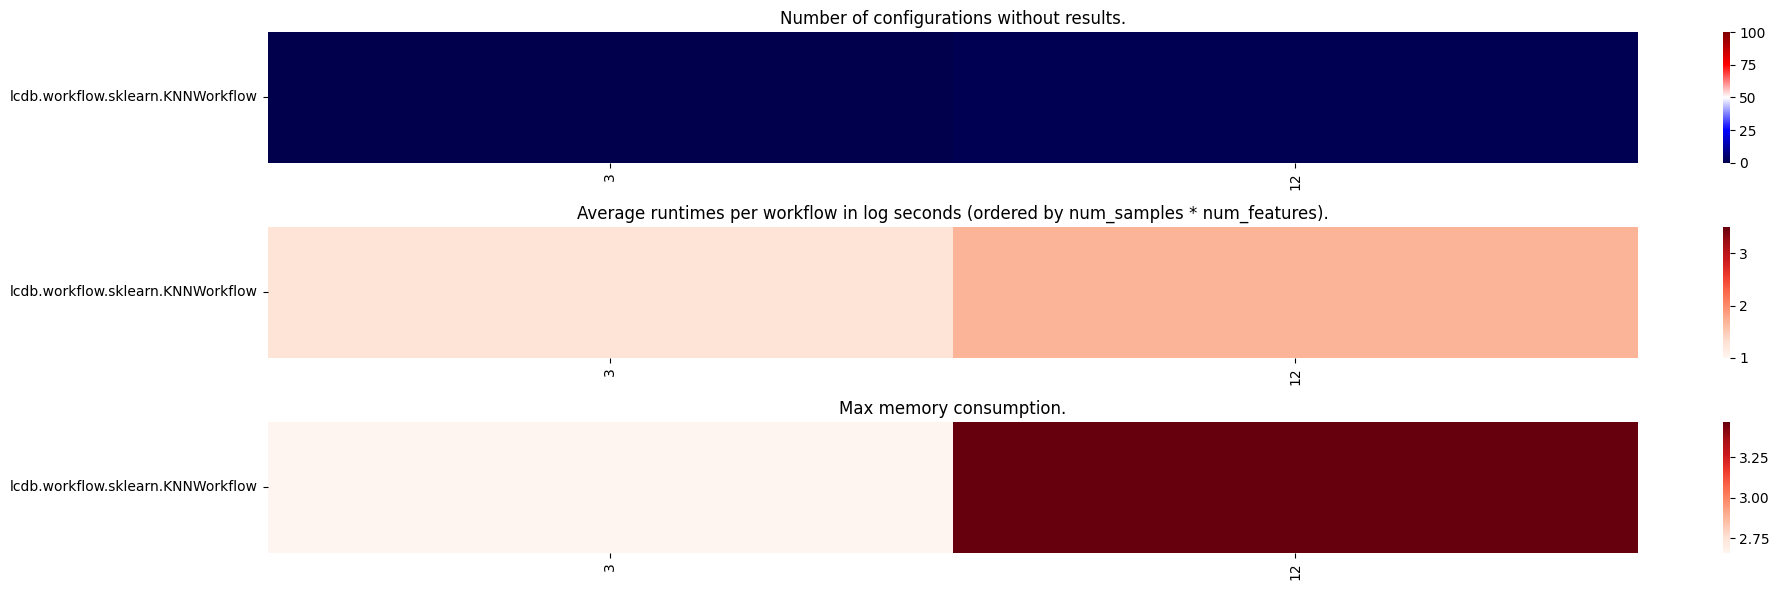

1834.8811997969945
0.2094613241777391


In [12]:
import matplotlib.pyplot as plt
import seaborn as sb

fig, axs = plt.subplots(3, 1, figsize=(20, 6))

# show data availability
ax = axs[0]
sb.heatmap(100 - num_datapoints, ax=ax, cmap="seismic", center=50, vmin=0, vmax=100)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Number of configurations without results.")

# show runtimes
ax = axs[1]
sb.heatmap(np.log10(mean_runtimes), ax=ax, cmap="Reds", annot=False, fmt=".1f", vmin=1, vmax=3.5)
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Average runtimes per workflow in log seconds (ordered by num_samples * num_features).")

# show max memory
ax = axs[2]
sb.heatmap(np.log10(max_memory_requirements / 1024**2), ax=ax, cmap="Reds")
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Max memory consumption.")


fig.tight_layout()
plt.show()

print((np.nansum(mean_runtimes) * 10**5) / 3600)
print((np.nansum(mean_runtimes) * 10**5) / 86400 / 365)



In [36]:
d_datasets

[3, 12]

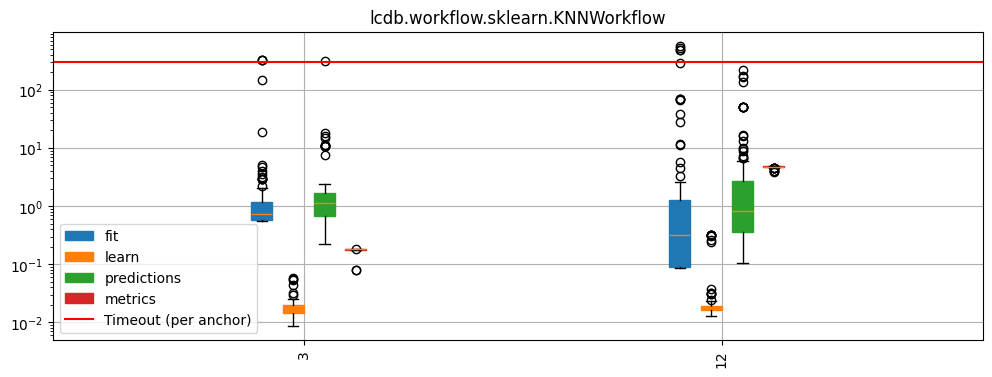

In [65]:
fig, axs = plt.subplots(len(dfs), 1, figsize=(12, 4 * len(dfs)))
if not isinstance(axs, np.ndarray):
    axs = np.array([axs])
axs = axs.reshape(-1, 1)

box_width = 0.05
for workfow, ax in zip(dfs.keys(), axs.flatten()):
    ax.set_title(workflow)
    #tags = dfs[workflow]["runtimes"].iloc[0]["summary"].keys()
    tags = ["fit", "learn", "predictions", "metrics"]
    boxes = {
        tag: []
        for tag in tags
    }
    for openmlid in d_datasets:
        df_dataset = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        runtimes_across_configs = [r["summary"] for r in df_dataset["runtimes"] if r is not None]
        for tag in tags:
            boxes[tag].append([r[tag] for r in runtimes_across_configs])
    drawn_boxes = {}
    for i, tag in enumerate(tags):
        drawn_boxes[tag] = ax.boxplot(boxes[tag], widths=box_width, positions=box_width * 1.5 * i + np.arange(len(d_datasets)), patch_artist=True, label=tag)
    
    # set colors for times
    for i, tag in enumerate(tags):
        if tag in drawn_boxes:
            for box in drawn_boxes[tag]["boxes"]:
                box.set(facecolor=f"C{i}", edgecolor=f"C{i}")

    ax.grid()
    ax.axhline(300, color="red", label="Timeout (per anchor)")
    ax.legend()
    ax.set_yscale("log")
    ax.set_xticks(len(tags) * box_width / 2 + np.arange(len(d_datasets)))
    ax.set_xticklabels(d_datasets, rotation=90)
plt.show()

In [10]:
from lcdb.analysis.views._debugger import Debugger
workflow = "lcdb.workflow.sklearn.KNNWorkflow"
df_debug = dfs[workflow][dfs[workflow]["m:openmlid"] == 1111].copy()
df_debug["runtime"] = df_debug["m:timestamp_end"] - df_debug["m:timestamp_start"]
df_debug = df_debug[df_debug["runtime"] > 1000]
debugger = Debugger()
debugger.load_data(df=df_debug)


In [17]:
debugger.get_cli_test_command()

961    lcdb test -i 1111 -w lcdb.workflow.sklearn.KNN...
963    lcdb test -i 1111 -w lcdb.workflow.sklearn.KNN...
988    lcdb test -i 1111 -w lcdb.workflow.sklearn.KNN...
dtype: object

# Extrapolate Compute
We extrapolate
$$\begin{align*}
    \mathbb{E}[\text{runtime on first c configs with first s seed combinations}] &= \mathbb{E}\left[\sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\text{ runtime of first c configs of workflow on }\mathit{D}\text{ and seed combination}\right]\\
    &= \sum_{\text{workflow}}\sum_\mathit{D}\sum_{\text{seed combination}}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and seed combination}\right]\\
    &\approx |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{ runtime of first c configs of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]\\
    &\approx c\cdot |\text{\# seed combinations}| \cdot\sum_{\text{workflow}}\sum_\mathit{D}\mathbb{E}\left[\text{any config of workflow $w$ on }\mathit{D}\text{ and any seed combination}\right]
\end{align*}
$$
Here we assume that the expected runtime is the same for all configs and seeds, which is the case if we do not condition on specific such configs and seeds.

This motivates to create a matrix with estimates of mean runtimes, which would be the estimates of the $\mathbb{E}$ in the sum.

Overall expected runtime for 5 test seeds, 5 validation seeds, 1 workflow seeds, and 100000 configs overall is 0.6 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.KNNWorkflow is 0.0 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.LibLinearWorkflow is 0.0 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.LibSVMWorkflow is 0.0 million CPU hours
	Overall expected runtime for lcdb.workflow.sklearn.TreesEnsembleWorkflow is 0.4 million CPU hours
	Overall expected runtime for lcdb.workflow.xgboost.XGBoostWorkflow is 0.1 million CPU hours


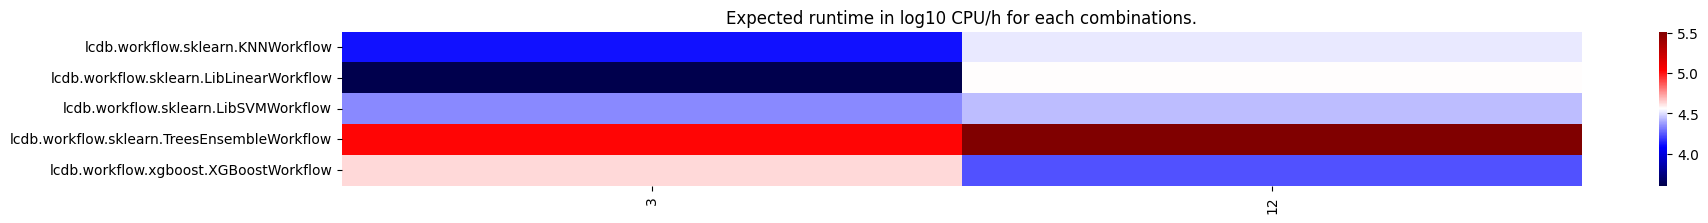

In [11]:
num_test_seeds_to_extrapolate_to = 5
num_valid_seeds_to_extrapolate_to = 5
num_workflow_seeds_to_extrapolate_to = 1
num_configs_to_extrapolate_to = 10**5
total_expected_entries = num_test_seeds_to_extrapolate_to * num_valid_seeds_to_extrapolate_to * num_workflow_seeds_to_extrapolate_to * num_configs_to_extrapolate_to
ratio_available_entries = num_datapoints / total_expected_entries

fig, ax = plt.subplots(1, 1, figsize=(20, 2))

# show data availability
expected_overall_runtimes = (mean_runtimes * total_expected_entries) / 3600
expected_remaining_runtimes = expected_overall_runtimes * (1 - ratio_available_entries)
sb.heatmap(np.log10(expected_remaining_runtimes), ax=ax, cmap="seismic")
ax.set_xticks(0.5 + np.arange(len(d_datasets)))
ax.set_xticklabels(d_datasets, rotation=90)
ax.set_yticklabels(d_workflows, rotation=0)
ax.set_title(f"Expected runtime in log10 CPU/h for each combinations.")

print(f"Overall expected runtime for {num_test_seeds_to_extrapolate_to} test seeds, {num_valid_seeds_to_extrapolate_to} validation seeds, {num_workflow_seeds_to_extrapolate_to} workflow seeds, and {num_configs_to_extrapolate_to} configs overall is {np.round(np.sum(expected_overall_runtimes) / 10**6, 1)} million CPU hours")
for i, workflow in enumerate(d_workflows):
    print(f"\tOverall expected runtime for {workflow} is {np.round(np.sum(expected_overall_runtimes[i]) / 10**6, 1)} million CPU hours")

# Memory Requirements

In [13]:
max_memory_requirements = np.zeros((len(d_workflows), len(d_datasets)))
for i, workflow in enumerate(d_workflows):
    for j, openmlid in enumerate(d_datasets):
        df_detail = dfs[workflow][dfs[workflow]["m:openmlid"] == openmlid]
        if len(df_detail) == 0:
            mean_runtimes[i, j] = np.nan
        else:
            num_datapoints[i, j] = len(df_detail[df_detail["has_result"]])
            mean_runtimes[i, j] = (df_detail["m:timestamp_end"] - df_detail["m:timestamp_start"]).mean()
